# Supplemental Feature Plot

Kendra Wyant  
July 29, 2024

### Set Up Environment

In [ ]:

# handle conflicts
options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/fun_ml.R?raw=true")


ℹ SHA-1 hash of file is "77e91675366f10788c6bcb59fa1cfc9ee0c75281"

In [ ]:

suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(tidymodels))
library(kableExtra, exclude = "group_rows")


theme_set(theme_classic()) 


In [ ]:

devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "75cc6f7b855da59c240908bd936834b4da01285b"

In [ ]:
path_processed <- format_path(str_c("studydata/risk/data_processed/lag"))
path_models_lag <- format_path(str_c("studydata/risk/models/lag"))
path_chtc <- format_path(str_c("studydata/risk/chtc/lag/train_xgboost_1week_0lag_nested_1_x_10_3_x_10_v2_main/input"))

source(here::here(path_chtc, "training_controls.R"))


### Read in Data

In [ ]:
global_all <- read_rds(here::here(path_models_lag, "shap_global_all.rds")) |> 
   filter(!variable_grp %in% c("day of week (other)", "time of day (other)")) |> 
   mutate(variable_grp = reorder(variable_grp, mean_value, sum),
          model = factor(model, c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag")))

shap_levels <- global_all |>
  mutate(variable_grp = reorder(variable_grp, mean_value, sum)) |>
  pull(variable_grp) |>
  levels()

shap_feat <- read_rds(here::here(path_models_lag, "outer_shapsgrp_with_features_1week_336_v1_nested_main.rds")) |> 
  filter(!variable_grp %in% c("lapse hour (other)", "lapse day (other)")) |>
  mutate(variable_grp = factor(variable_grp, levels = shap_levels)) |> 
  glimpse()


Rows: 3,981,708
Columns: 4
Groups: id_obs [221,206]
$ id_obs               <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ variable_grp         <fct> age (demographic), education (demographic), emplo…
$ value                <dbl> 0.0003532865, 0.0007736921, 0.0080574297, -0.0429…
$ feature_score_z_mean <dbl> 1.31538363, -0.54076535, 1.39309011, -0.71951059,…

### Downsample data

In [ ]:
downsample_ratio <- .10
set.seed(102030)

ids <- shap_feat |>
  pull(id_obs) |>
  unique()

ids <- ids |> sample(size = round(length(ids)/(1/downsample_ratio)))

shap_feat_down <- shap_feat |> 
  filter(id_obs %in% ids)


### Create plot

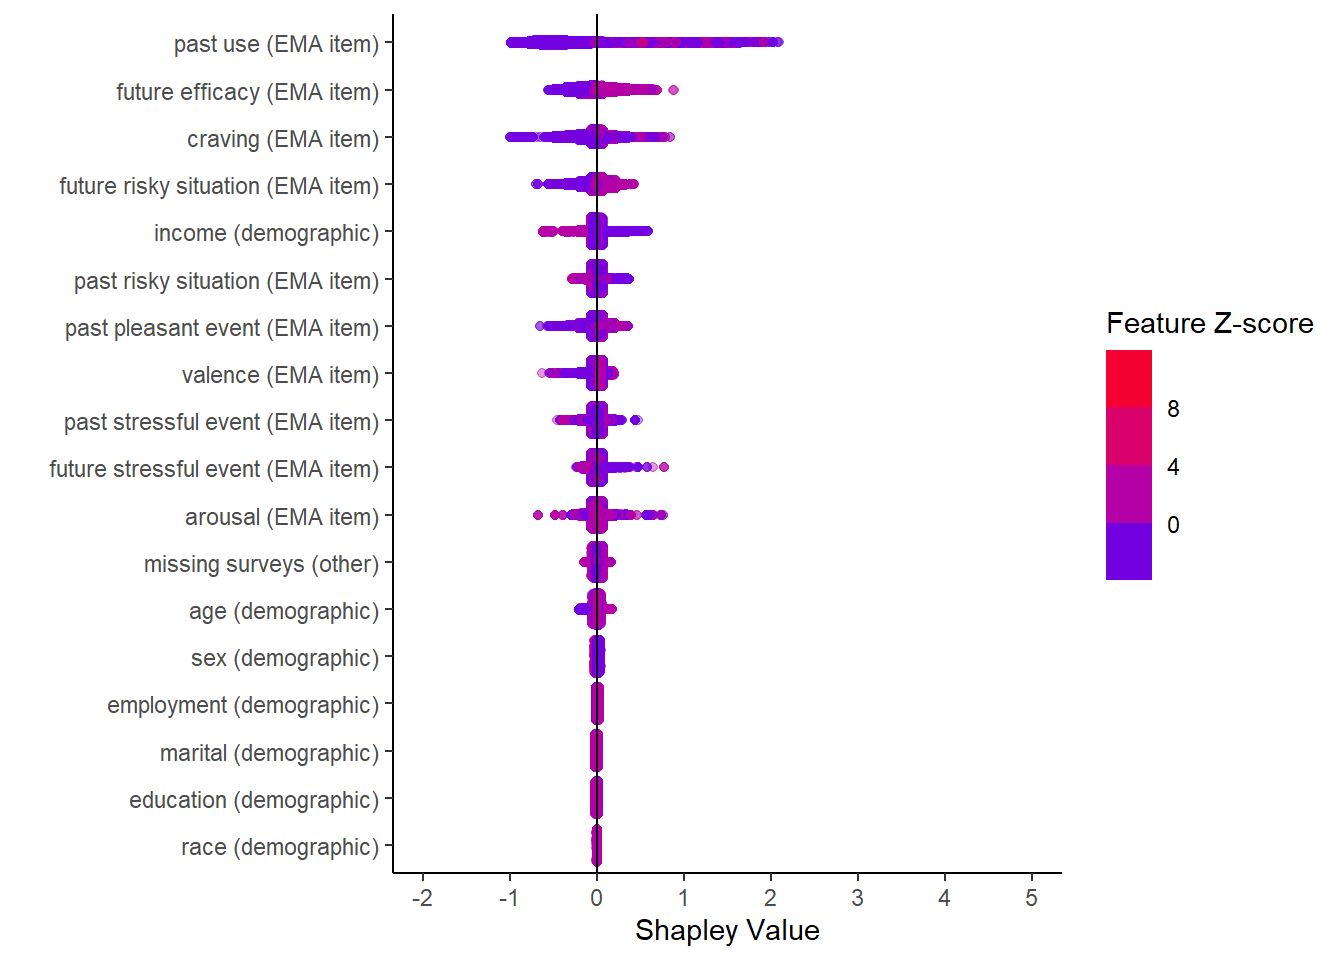

In [ ]:
shap_feat_down |>
  ggplot(mapping = aes(x = variable_grp, y = value, color = feature_score_z_mean)) +
  ggforce::geom_sina(method = "counts", maxwidth = 0.7, alpha = .4) +
  geom_hline(yintercept = 0) +
  scale_y_continuous(limits = c(-2, 5), breaks = seq(-2, 5)) +
  ylab("Shapley Value") +
  xlab("") +
  scale_color_binned(low = "blue", high = "red") +
  labs(color = "Feature Z-score") +
  coord_flip()
